# Fig. 5 — Xenium human breast cancer data analysis

Reproduces Fig. 5b-k; Fig. 5a is the manual tumor-region annotation and is not generated
here.

Data — set `SVC_DATA_ROOT` to the directory holding the prepared Xenium human breast cancer arrays
(default: `../../data/xenium_breast_cancer`)
- cell coordinates of both sections

Precomputed files — `precomputed/`, shipped with this notebook
- `adjacency_matrix_SVC.npz`, `adjacency_matrix_spatial.npz` — the co-localization and
  spatial graphs; node order is rep1 then rep2 (Fig. 5b)
- `coloc_multi.npz` — per-cell-type gene-gene co-localization scores (Fig. 5d)
- `myoepi_polarity_coefficients.npz` — per-gene signed loading on the basal-apical axis of
  ACTA2+ myoepithelial cells (Fig. 5e)
- `myoepi_transcripts.npz` — myoepithelial transcript positions and each cell's basal axis
  (Fig. 5e)
- `myoepi_tissue_panel.npz` — cell boundaries, nuclei and transcripts of one duct in section 1
  (Fig. 5f)
- `go_poles_panel.csv` — Enrichr terms for the two gene groups (Fig. 5g)
- `cxcl12_partner_shift.csv` — per partner gene, its co-localization with *CXCL12* in
  endothelial cells of the three spatial contexts (Fig. 5h)
- `lum_depletion_effects.csv` — cell-level and subcellular response of the 65 readout genes
  to *in silico* depletion of *LUM* in stromal cells (Fig. 5i)
- `lum_depletion_maps_CRISPLD2.npz` — predicted 12 x 12 maps of *CRISPLD2* before and after
  *LUM* depletion (Fig. 5j)
- `lum_depletion_POSTN.npz` — the same maps for *POSTN*, with each cell's spatial context
  (Fig. 5k)

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import load_npz

HERE = Path.cwd()

sys.path.insert(0, str(Path(os.environ.get('SVC_ROOT', HERE / '../..'))))   # github.com/aster-ww/SVC
from svc.spatial_domain import spatial_domains

DATA_DIR = Path(os.environ.get('SVC_DATA_ROOT', HERE / '../../data')) / 'xenium_breast_cancer'

location_rep1 = np.load(DATA_DIR / 'cell_location_rep1.npy')
location_rep2 = np.load(DATA_DIR / 'cell_location_rep2.npy')
location_rep2_aligned = np.load(DATA_DIR / 'cell_location_rep2_aligned.npy')
print(location_rep1.shape, location_rep2.shape)

(60914, 2) (43252, 2)


## Fig. 5b — spatial domains detected by SVC in both sections

cells 104166 | domains 17 | unassigned 6


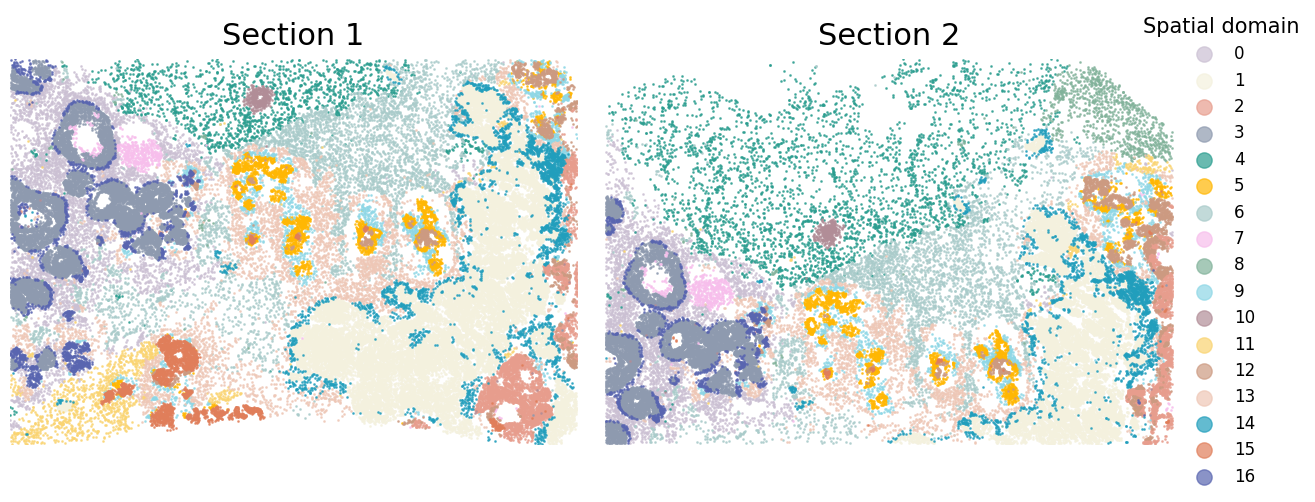

In [2]:
# Fig. 5b
K_DOMAIN = 17
COLORS = ['#cbc0d3', '#f4f1de', '#e79d8d', '#8e9aaf', '#2A9D8F', '#ffb703', '#A9CBCA',
          '#F7BEEC', '#81b29a', '#8ed7e6', '#B18D97', '#FAD471', '#CC9A81', '#eec7b6',
          '#219ebc', '#E07E5A', '#5965B0']

svc_graph = load_npz(HERE / 'precomputed/adjacency_matrix_SVC.npz')
spatial_graph = load_npz(HERE / 'precomputed/adjacency_matrix_spatial.npz')
labels = spatial_domains(svc_graph, spatial_graph, K_DOMAIN)
labels_rep1, labels_rep2 = labels[:len(location_rep1)], labels[len(location_rep1):]
print('cells %d | domains %d | unassigned %d' % (len(labels), K_DOMAIN, (labels == -1).sum()))

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'wspace': 0.05})
for domain in range(K_DOMAIN):
    for a, loc, lab in [(ax[0], location_rep1, labels_rep1), (ax[1], location_rep2, labels_rep2)]:
        keep = lab == domain
        a.scatter(loc[keep, 0], loc[keep, 1], s=1, alpha=0.7, c=COLORS[domain], label=str(domain))

for a, loc, title in [(ax[0], location_rep1, 'Section 1'), (ax[1], location_rep2, 'Section 2')]:
    a.set_title(title, fontsize=22, pad=10)
    a.set_xlim(loc[:, 0].min(), loc[:, 0].max())
    a.set_ylim(loc[:, 1].min(), loc[:, 1].max())
    a.invert_xaxis()
    a.axis('off')

plt.legend(title='Spatial domain', loc='upper right', bbox_to_anchor=(1.25, 1.15), markerscale=11,
           fontsize=12.1, frameon=False, title_fontsize=15)
plt.show()

## Fig. 5c — mean expression (log1p-transformed) of five marker genes in each spatial domain

The solid arrow indicates the highest value.

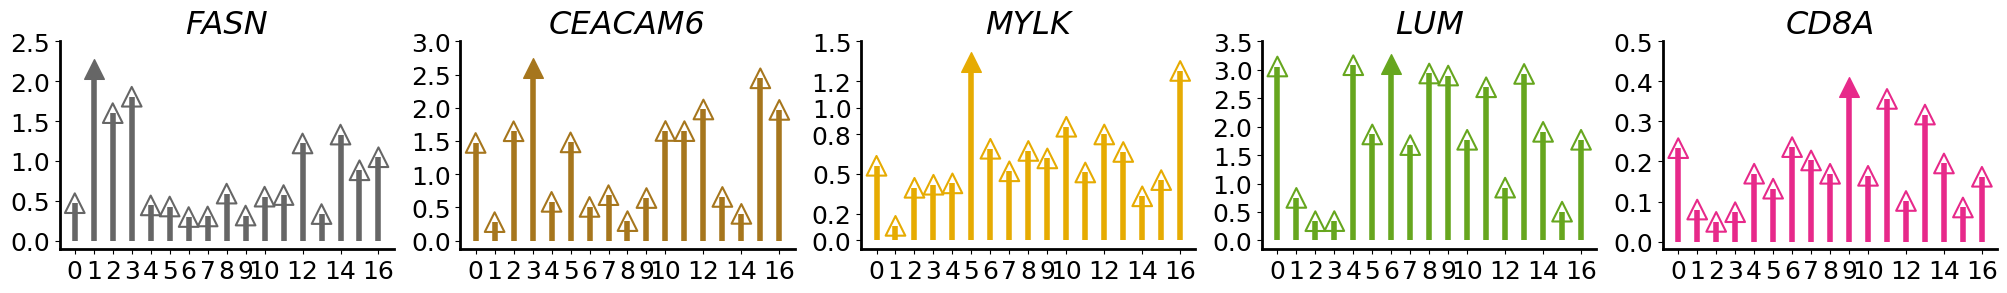

In [3]:
# Fig. 5c
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)
    import scanpy as sc

MARKERS = ['FASN', 'CEACAM6', 'MYLK', 'LUM', 'CD8A']
XTICKS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14, 16]

expression = []
for rep, section_labels in [('rep1', labels_rep1), ('rep2', labels_rep2)]:
    counts = sc.read_10x_h5(DATA_DIR / f'cell_feature_matrix_{rep}.h5')
    names = np.loadtxt(DATA_DIR / f'cell_names_{rep}.txt', dtype=str)
    row = {c: i for i, c in enumerate(counts.obs.index)}
    column = [list(counts.var.index).index(g) for g in MARKERS]
    expression.append(np.asarray(counts.X[:, column][[row[c] for c in names]].todense()))
expression = np.vstack(expression)

mean_log1p = np.array([[np.log1p(expression[labels == d, j]).mean() for d in range(K_DOMAIN)]
                       for j in range(len(MARKERS))])

palette = [plt.get_cmap('Dark2_r')(i) for i in range(len(MARKERS))]
fig, ax = plt.subplots(1, len(MARKERS), figsize=(25, 2.7),
                       gridspec_kw={'wspace': 0.2, 'hspace': 0.4})
x = np.arange(K_DOMAIN)
for k, (gene, color, a) in enumerate(zip(MARKERS, palette, ax)):
    height = mean_log1p[k]
    peak = np.argsort(height)[::-1][:1]
    rest = np.argsort(height)[::-1][1:]
    a.vlines(x=x, ymin=0, ymax=height, colors=color, linewidth=4)
    a.scatter(x[rest], height[rest], edgecolor=color, s=200, marker='^',
              facecolor='none', linewidth=1.5)
    a.scatter(x[peak], height[peak], color=color, s=200, marker='^')
    a.set_xticks(XTICKS); a.set_xticklabels(XTICKS, fontsize=18)
    ticks = np.round([t for t in a.get_yticks() if t >= 0], 1)
    a.set_yticks(ticks); a.set_yticklabels(ticks, fontsize=18)
    a.set_title(gene, fontsize=23, fontstyle='italic')
    a.spines['top'].set_visible(False); a.spines['right'].set_visible(False)
    a.spines['left'].set_linewidth(2); a.spines['bottom'].set_linewidth(2)

plt.show()

## Fig. 5d — gene co-localization scores of cell-type-specific gene pairs across six cell types

For each cell type, the pair shown is the one whose score most exceeds its average across cell
types. Grey indicates pairs detected in fewer than 20 cells of that cell type.

DCIS_1           CEACAM6-GATA3          0.894
DCIS_2           CEACAM6-EPCAM          0.907
Invasive_Tumor   ANKRD30A-POLR2J3       0.805
Myoepi_ACTA2+    KRT14-MYLK             0.910
Stromal          CCDC80-CXCL12          0.780
B_Cells          ITM2C-TPD52            0.785


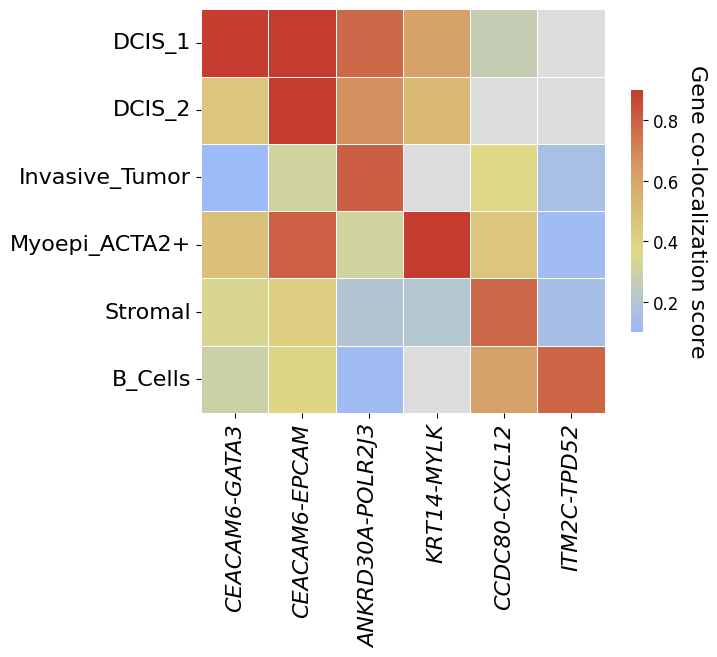

In [4]:
# Fig. 5d
import warnings

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

MIN_CELLS = 20
CELL_TYPES = ['DCIS_1', 'DCIS_2', 'Invasive_Tumor', 'Myoepi_ACTA2+', 'Stromal', 'B_Cells']

_c = np.load(HERE / 'precomputed/coloc_multi.npz', allow_pickle=True)
score, detected, types = _c['score_fine'], _c['fine_valid'], list(_c['fine_types'])
gene_names = list(_c['gene_names'])
n_genes = len(gene_names)

eligible = detected >= MIN_CELLS
ia, ib = np.triu_indices(n_genes, 1)
pair_score = score[:, ia, ib]                                  # (type, pair)
pair_ok = eligible[:, ia] & eligible[:, ib]
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    pair_mean = np.nanmean(np.where(pair_ok, pair_score, np.nan), 0)

chosen = []
for name in CELL_TYPES:
    t = types.index(name)
    specificity = np.where(pair_ok[t], pair_score[t] - pair_mean, -9)
    chosen.append((name, t, int(np.argmax(specificity))))

pair_labels = ['%s-%s' % (gene_names[ia[k]], gene_names[ib[k]]) for _, _, k in chosen]
grid = np.full((len(chosen), len(chosen)), np.nan)
for r, (_, t, _) in enumerate(chosen):
    for c, (_, _, k) in enumerate(chosen):
        i, j = ia[k], ib[k]
        if eligible[t, i] and eligible[t, j]:
            grid[r, c] = score[t, i, j]

cmap = LinearSegmentedColormap.from_list('coloc', ['#98B9FF', '#DFD987', '#D69F67', '#C63B30'])
cmap.set_bad('#dddddd')
fig, ax = plt.subplots(figsize=(7.5, 6.5))
hm = sns.heatmap(grid, cmap=cmap, vmin=0.1, vmax=0.9, ax=ax, linewidths=.5, linecolor='white',
                 square=True, xticklabels=pair_labels, yticklabels=[c[0] for c in chosen],
                 cbar_kws={'label': 'Gene co-localization score', 'shrink': .6})
cbar = hm.collections[0].colorbar
cbar.set_label('Gene co-localization score', fontsize=16, rotation=270, labelpad=20)
cbar.ax.tick_params(labelsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=16, fontstyle='italic')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=16)

for (name, t, k), label in zip(chosen, pair_labels):
    print('%-16s %-22s %.3f' % (name, label, score[t, ia[k], ib[k]]))

fig.tight_layout()
plt.show()

## Fig. 5e — signed loading of each gene on the basal-apical axis of ACTA2+ myoepithelial cells, transcript densities of the two gene groups along the axis, and the per-cell transcript centroid of each group

Transcript positions are projected onto the anatomy-derived axis from -1 (apical) to 1 (basal);
the ten most basal and ten most apical genes are labelled. P values from a two-sided Wilcoxon
signed-rank test.

62 genes | first component explains 62.8% of the variance | basal 24 apical 38


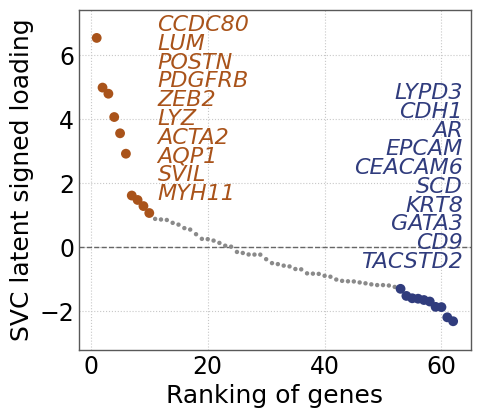

4528 cells with >=5 transcripts from each pole | log2 ratio -1.45 .. +1.57


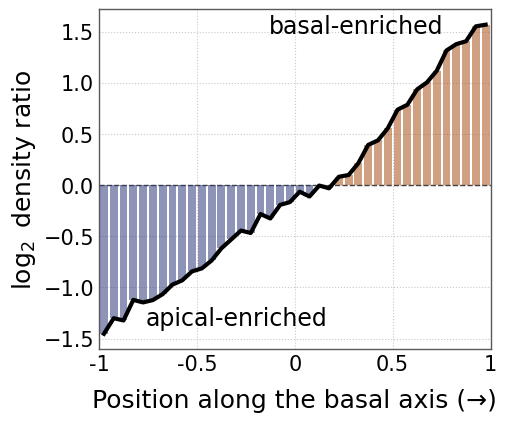

4528 cells | basal median +0.196  apical median -0.066 | paired Wilcoxon p = 0.0e+00 -> ***
basal > apical in 81.8% of cells


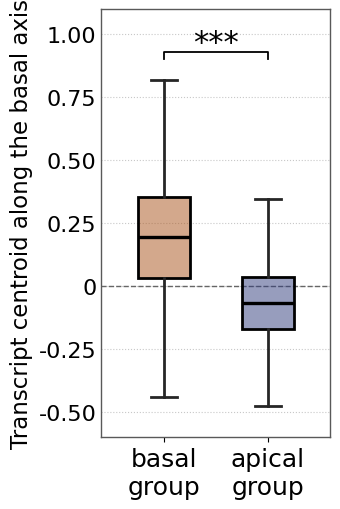

In [5]:
# Fig. 5e
from matplotlib.colors import to_rgba
from scipy.stats import wilcoxon

N_LABEL, MIN_TX, N_BINS = 10, 5, 40
RED, BLUE, GREY = '#a9531a', '#303c7d', '#8A8A8A'

_p = np.load(HERE / 'precomputed/myoepi_polarity_coefficients.npz', allow_pickle=True)
coefficients, polarity_genes = _p['coefficients'], list(_p['genes'])

U, S, _ = np.linalg.svd(coefficients - coefficients.mean(0), full_matrices=False)
alpha = U[:, 0] * S[0]
alpha = alpha * np.sign(alpha[np.argmax(np.abs(alpha))])
print('%d genes | first component explains %.1f%% of the variance | basal %d apical %d'
      % (len(alpha), 100 * S[0] ** 2 / (S ** 2).sum(), (alpha > 0).sum(), (alpha < 0).sum()))

order = np.argsort(alpha)[::-1]
ranked_alpha, ranked_genes = alpha[order], [polarity_genes[i] for i in order]
n = len(order)
color = [GREY] * n
size = [10] * n
for i in list(range(N_LABEL)) + list(range(n - N_LABEL, n)):
    color[i] = RED if i < N_LABEL else BLUE
    size[i] = 50

fig, ax = plt.subplots(figsize=(4.5, 4))
fig.subplots_adjust(left=0.10, right=0.97, top=0.96, bottom=0.11)
ax.set_facecolor('white')
ax.grid(True, color='#C8C8C8', lw=0.8, ls=':', zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('0.35'); spine.set_linewidth(1.0)

ax.scatter(np.arange(1, n + 1), ranked_alpha, c=color, s=size, edgecolor='none', zorder=3)
pad = 0.10 * (ranked_alpha.max() - ranked_alpha.min())
ax.set_xlim(-2, n + 3)
ax.set_ylim(ranked_alpha.min() - pad, ranked_alpha.max() + pad)
ax.set_xticks([0, 20, 40, 60]); ax.set_xticklabels(['0', '20', '40', '60'], fontsize=15)
ax.set_xlabel('Ranking of genes', fontsize=18)
ax.set_ylabel('SVC latent signed loading', fontsize=18)
ax.axhline(0, color='0.4', lw=1.0, ls='--', zorder=2)
ax.tick_params(axis='both', which='major', length=0, labelsize=17)

for k, gene in enumerate(ranked_genes[:N_LABEL]):
    ax.text(0.2, 0.955 - k * 0.055, gene, transform=ax.transAxes, ha='left', va='center',
            fontsize=16, color=RED, fontstyle='italic', zorder=4)
for k, gene in enumerate(ranked_genes[n - N_LABEL:][::-1]):
    ax.text(0.98, 0.755 - k * 0.055, gene, transform=ax.transAxes, ha='right', va='center',
            fontsize=16, color=BLUE, fontstyle='italic', zorder=4)

plt.show()

BASAL, APICAL = ranked_genes[:N_LABEL], ranked_genes[n - N_LABEL:][::-1]

_t = np.load(HERE / 'precomputed/myoepi_transcripts.npz', allow_pickle=True)
tx_genes = list(_t['genes'])
basal_idx = np.array([tx_genes.index(g) for g in BASAL if g in tx_genes])
apical_idx = np.array([tx_genes.index(g) for g in APICAL if g in tx_genes])

def per_cell_projection():
    """for every cell with enough transcripts of both poles, each transcript's position on the
    cell's basal axis, split by pole"""
    for rep in ['rep1', 'rep2']:
        cell = _t[f'{rep}_cell']; gene = _t[f'{rep}_gene']
        ratio = _t[f'{rep}_ratio'].astype(np.float64)
        angle = np.radians(_t[f'{rep}_angle'].astype(np.float64))
        basal_angle = _t[f'{rep}_basal_angle']

        order = np.argsort(cell, kind='stable')
        cell, gene, ratio, angle = cell[order], gene[order], ratio[order], angle[order]
        edge = np.searchsorted(cell, np.arange(cell.max() + 2))
        for c in np.unique(cell):
            if not np.isfinite(basal_angle[c]):
                continue
            s, e = edge[c], edge[c + 1]
            in_basal = np.isin(gene[s:e], basal_idx)
            in_apical = np.isin(gene[s:e], apical_idx)
            if in_basal.sum() < MIN_TX or in_apical.sum() < MIN_TX:
                continue
            u = ratio[s:e] * np.cos(angle[s:e] - basal_angle[c])
            yield u, in_basal, in_apical

centers = np.linspace(-1, 1, N_BINS + 1)[:-1] + 1.0 / N_BINS
basal_hist, apical_hist = [], []
basal_mean, apical_mean = [], []
for u, in_basal, in_apical in per_cell_projection():
    bin_index = np.clip(((u + 1) / 2 * N_BINS).astype(int), 0, N_BINS - 1)
    for mask, store in ((in_basal, basal_hist), (in_apical, apical_hist)):
        h = np.bincount(bin_index[mask], minlength=N_BINS).astype(np.float32)
        store.append(h / h.sum())
    basal_mean.append(u[in_basal].mean()); apical_mean.append(u[in_apical].mean())
basal_hist, apical_hist = np.array(basal_hist), np.array(apical_hist)
basal_mean, apical_mean = np.array(basal_mean), np.array(apical_mean)

log_ratio = np.log2((basal_hist.sum(0) / basal_hist.sum()) / (apical_hist.sum(0) / apical_hist.sum()))
print('%d cells with >=%d transcripts from each pole | log2 ratio %+.2f .. %+.2f'
      % (len(basal_hist), MIN_TX, log_ratio.min(), log_ratio.max()))

fig, ax = plt.subplots(figsize=(4.5, 4))
fig.subplots_adjust(left=0.10, right=0.97, top=0.96, bottom=0.11)
ax.set_facecolor('white')
ax.grid(True, color='#C8C8C8', lw=0.8, ls=':', zorder=0); ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('0.35'); spine.set_linewidth(1.0)

ax.axhline(0, color='0.25', lw=1.0, ls='--', zorder=2)
ax.bar(centers, log_ratio, width=(2.0 / N_BINS) * 0.8, alpha=0.55, edgecolor='none', zorder=3,
       color=[RED if v > 0 else BLUE for v in log_ratio])
ax.plot(centers, log_ratio, color='k', lw=3, zorder=4)
ax.set_xticks([-1, -0.5, 0, 0.5, 1]); ax.set_xticklabels(['-1', '-0.5', '0', '0.5', '1'], fontsize=15)
ax.set_xlim(-1, 1)
ax.set_xlabel('Position along the basal axis (\u2192)', fontsize=18, labelpad=10)
ax.set_ylabel(r'$\log_2$ density ratio', fontsize=18)
ax.tick_params(axis='both', which='major', length=0, labelsize=15)
ax.text(0.88, 0.95, 'basal-enriched', transform=ax.transAxes, fontsize=17, ha='right', va='center', zorder=5)
ax.text(0.12, 0.09, 'apical-enriched', transform=ax.transAxes, fontsize=17, ha='left', va='center', zorder=5)

plt.show()

p_value = wilcoxon(basal_mean, apical_mean).pvalue
stars = '***' if p_value < 1e-3 else '**' if p_value < 1e-2 else '*' if p_value < 0.05 else 'n.s.'
print('%d cells | basal median %+.3f  apical median %+.3f | paired Wilcoxon p = %.1e -> %s'
      % (len(basal_mean), np.median(basal_mean), np.median(apical_mean), p_value, stars))
print('basal > apical in %.1f%% of cells' % (100 * ((basal_mean - apical_mean) > 0).mean()))

fig, ax = plt.subplots(figsize=(3.5, 5.2))
ax.set_facecolor('white')
ax.grid(True, axis='y', color='#C8C8C8', lw=0.8, ls=':', zorder=0); ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('0.35'); spine.set_linewidth(1.0)

box = ax.boxplot([basal_mean, apical_mean], positions=[0, 1], widths=0.5, patch_artist=True,
                 showfliers=False, zorder=6)
for patch, color in zip(box['boxes'], [RED, BLUE]):
    patch.set(facecolor=to_rgba(color, 0.5), edgecolor='k', linewidth=2)
for part in ('whiskers', 'caps'):
    for element in box[part]:
        element.set(color='0.15', linewidth=2)
for median in box['medians']:
    median.set(color='k', linewidth=2.4)

ax.axhline(0, color='0.4', lw=1.0, ls='--', zorder=2)
ax.set_xticks([0, 1]); ax.set_xticklabels(['basal\ngroup', 'apical\ngroup'], fontsize=18)
ax.set_yticks([-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
ax.set_yticklabels(['-0.50', '-0.25', '0', '0.25', '0.50', '0.75', '1.00'], fontsize=16)
ax.set_ylabel('Transcript centroid along the basal axis', fontsize=16.5)
ax.set_ylim(-0.6, 1.1); ax.set_xlim(-0.6, 1.6)
ax.tick_params(axis='y', length=0, labelsize=16)
ax.plot([0, 0, 1, 1], [0.9, 0.93, 0.93, 0.9], color='k', lw=1.3)
ax.text(0.5, 0.91, stars, ha='center', va='bottom', fontsize=22)

fig.tight_layout()
plt.show()

## Fig. 5f — representative ROI from section 1 showing observed transcript positions of the two ten-gene groups

Arrows mark the basal axis of each myoepithelial cell.

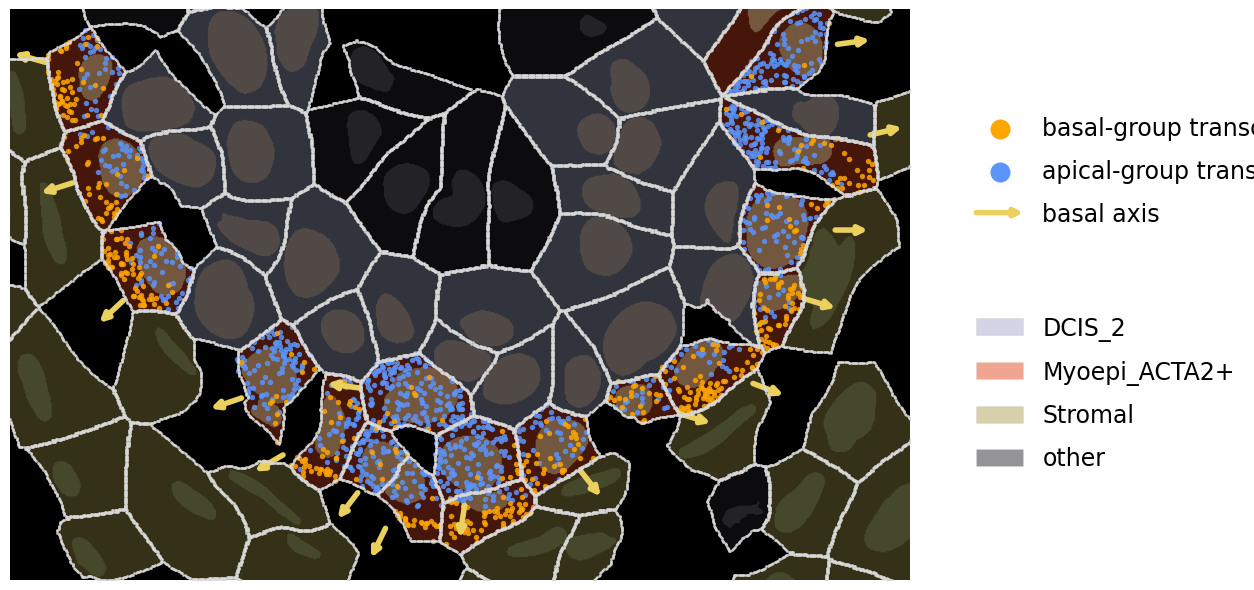

In [6]:
# Fig. 5f
from matplotlib.patches import Polygon, Patch, FancyArrowPatch
from matplotlib.legend_handler import HandlerPatch

ORANGE, BLUE_2, ARROW_UM, MAX_GAP = '#FFA500', '#5B94FB', 6.0, 3.0
FILL = {'Myoepi_ACTA2+': '#E54A21', 'DCIS_2': '#A7ADCD', 'Stromal': '#B1A355'}
NUC = {'Myoepi_ACTA2+': '#E1F0BD', 'DCIS_2': '#9C7A5C', 'Stromal': '#6E8055'}
FILL_OTHER, NUC_OTHER, EDGE, AXIS_C = '#2A2A30', '#5A5A63', '#D8D8D8', '#EAD05C'
AXFRAC = 0.71

_v = dict(np.load(HERE / 'precomputed/myoepi_tissue_panel.npz', allow_pickle=True))
types, nucleus, axis = _v['types'], _v['nucleus'], _v['axis']
x0, x1, y0, y1 = _v['frame']
panel_genes = list(_v['genes'])
basal_set = {panel_genes.index(g) for g in BASAL if g in panel_genes}
apical_set = {panel_genes.index(g) for g in APICAL if g in panel_genes}
span = lambda key, i: slice(_v[f'{key}_pointer'][i], _v[f'{key}_pointer'][i + 1])
tx_dx, tx_dy = _v['tx_dx'].astype(float), _v['tx_dy'].astype(float)

in_frame = [i for i in range(len(types))
            if types[i] == 'Myoepi_ACTA2+' and x0 < nucleus[i, 0] < x1 and y0 < nucleus[i, 1] < y1
            and np.isfinite(axis[i]).all()]

fig, ax = plt.subplots(figsize=(9 / AXFRAC, 9 * (y1 - y0) / (x1 - x0)))
fig.subplots_adjust(left=0.0, right=AXFRAC, bottom=0.0, top=1.0)
ax.set_facecolor('black')

for key, colors, other, zorder in [('cell', FILL, FILL_OTHER, 1), ('nucleus', NUC, NUC_OTHER, 2)]:
    for i in range(len(types)):
        points = _v[f'{key}_points'][span(key, i)]
        if not len(points):
            continue
        if _v[f'{key}_gap'][i] <= MAX_GAP:
            ax.add_patch(Polygon(points, closed=True, lw=0, ec='none', alpha=0.3, zorder=zorder,
                                 fc=colors.get(types[i], other)))
        if key == 'cell':
            ax.scatter(*points.T, color=EDGE, s=15, marker='.', alpha=0.9, lw=0, zorder=10)

for i in in_frame:
    s = span('tx', i)
    gene = _v['tx_gene'][s]
    x = nucleus[i, 0] + tx_dx[s]
    y = nucleus[i, 1] + tx_dy[s]
    is_basal = np.array([g in basal_set for g in gene])
    is_apical = np.array([g in apical_set for g in gene])
    ax.scatter(x[is_apical], y[is_apical], s=15, color=BLUE_2, alpha=0.85, lw=0, zorder=7)
    ax.scatter(x[is_basal], y[is_basal], s=15, color=ORANGE, alpha=0.85, lw=0, zorder=8)

    boundary = _v['cell_points'][span('cell', i)]
    if len(boundary):
        tail = nucleus[i] + float(((boundary - nucleus[i]) @ axis[i]).max()) * axis[i]
        ax.annotate('', xy=tuple(tail + ARROW_UM * axis[i]), xytext=tuple(tail), zorder=9,
                    arrowprops=dict(arrowstyle='-|>', color=AXIS_C, lw=4, mutation_scale=12,
                                    shrinkA=0, shrinkB=0))

class HandlerArrow(HandlerPatch):
    def create_artists(self, legend, orig, xd, yd, w, h, fs, trans):
        arrow = FancyArrowPatch((0, h / 2), (w, h / 2), arrowstyle='-|>', mutation_scale=11, lw=4,
                                color=AXIS_C, shrinkA=0, shrinkB=0)
        arrow.set_transform(trans)
        return [arrow]

visible = pd.Series([types[i] for i in range(len(types))
                     if x0 < nucleus[i, 0] < x1 and y0 < nucleus[i, 1] < y1]).value_counts()
named = [t for t in visible.index if t in FILL]
entries = [(t, t) for t in named]
if int(visible.drop(named, errors='ignore').sum()):
    entries.append((None, 'other'))

handles = [ax.scatter([], [], s=80, color=ORANGE, label='basal-group transcript'),
           ax.scatter([], [], s=80, color=BLUE_2, label='apical-group transcript')]
arrow_handle = FancyArrowPatch((0, 0), (1, 0), color=AXIS_C, label='basal axis')
ax.add_patch(arrow_handle); arrow_handle.set_visible(False)
legend_tx = ax.legend(handles=handles + [arrow_handle], handler_map={FancyArrowPatch: HandlerArrow()},
                      loc='upper left', bbox_to_anchor=(1.05, 0.85), ncol=1, fontsize=17,
                      markerscale=1.5, frameon=False, handletextpad=0.8, labelspacing=0.8)
ax.add_artist(legend_tx)
legend_type = ax.legend(handles=[Patch(fc=FILL.get(k, FILL_OTHER), ec=EDGE, lw=0.8, label=lab, alpha=0.5)
                                 for k, lab in entries],
                        loc='upper left', bbox_to_anchor=(1.05, 0.50), ncol=1, fontsize=17,
                        frameon=False, handletextpad=0.8, labelspacing=0.8)

ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect('equal')
ax.invert_xaxis()
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

## Fig. 5g — terms enriched in the genes with positive (basal) and negative (apical) loading

Enrichment computed with Enrichr; P values adjusted separately within each gene-set library
using the Benjamini-Hochberg procedure. The x axis is -log10 of the adjusted P value.

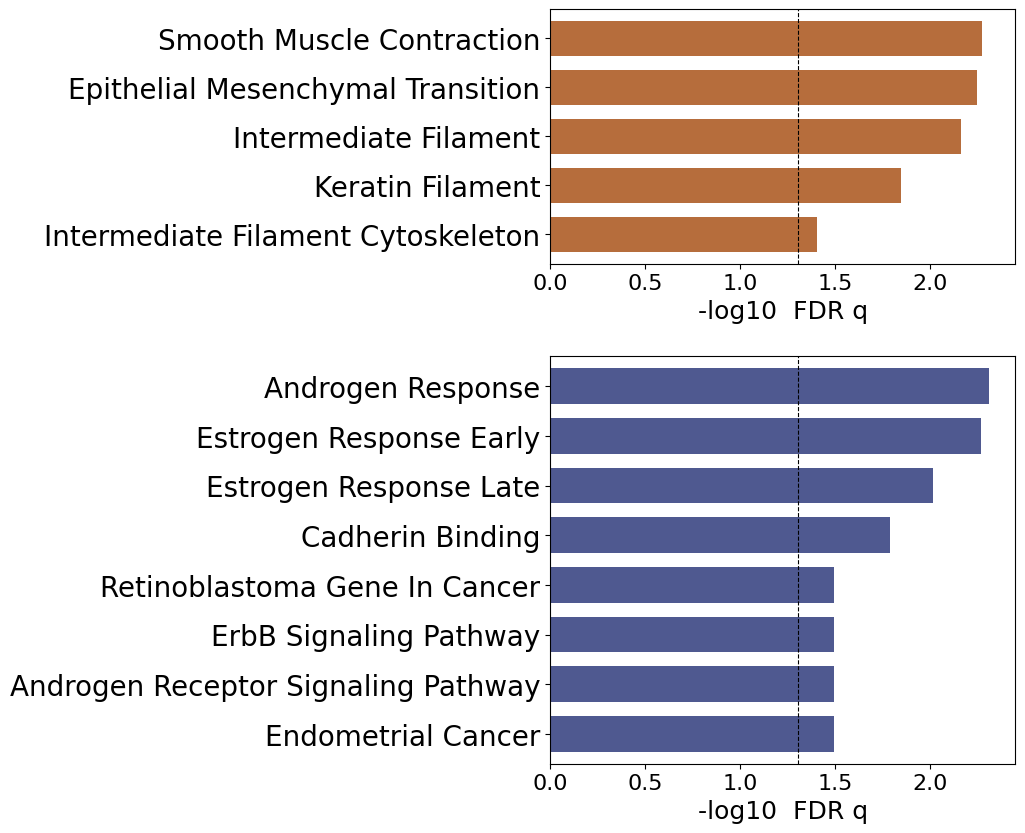

In [7]:
# Fig. 5g
N_TERMS, MIN_HITS = 8, 3
BAR_HEIGHT, BAR_WIDTH, MARGIN = 0.60, 6, 1.0

enrichment = pd.read_csv(HERE / 'precomputed/go_poles_panel.csv')
enrichment = enrichment[enrichment.Genes.str.split(';').apply(len) >= MIN_HITS]

def top_terms(pole, k=N_TERMS):
    d = enrichment[(enrichment.pole == pole) & (enrichment['Adjusted P-value'] < 0.05)]
    seen, keep = set(), []
    for _, row in d.sort_values('Adjusted P-value', kind='stable').iterrows():
        key = frozenset(row.Genes.split(';'))
        if key in seen:
            continue
        seen.add(key); keep.append(row)
        if len(keep) >= k:
            break
    return pd.DataFrame(keep)

basal, apical = top_terms('BASAL'), top_terms('APICAL')
short = lambda term: term.split(' R-HSA')[0].split(' (GO:')[0].split(' WP')[0][:52]

fig = plt.figure(figsize=(BAR_WIDTH, BAR_HEIGHT * (len(basal) + len(apical)) + 2 * MARGIN))
grid = fig.add_gridspec(2, 1, height_ratios=[len(basal), len(apical)],
                        hspace=0.28 / max(len(basal), len(apical)) * 8)
vmax = max([(-np.log10(d['Adjusted P-value'])).max() for d in (basal, apical) if len(d)] + [1.0])
for i, (d, color) in enumerate([(basal, RED), (apical, BLUE)]):
    ax = fig.add_subplot(grid[i])
    if len(d):
        d = d.iloc[::-1]
        y = np.arange(len(d))
        ax.barh(y, -np.log10(d['Adjusted P-value']), height=0.72, color=color, alpha=0.85)
        ax.set_yticks(y); ax.set_yticklabels([short(t) for t in d.Term], fontsize=20)
        ax.set_ylim(-0.6, len(d) - 0.4)
    ax.set_xlim(0, 1.06 * vmax)
    ax.axvline(-np.log10(0.05), color='k', ls='--', lw=0.8)
    ax.set_xlabel('-log10  FDR q', fontsize=18)
    ax.tick_params(axis='x', labelsize=16)

plt.show()

## Fig. 5h — change in co-localization with *CXCL12* in endothelial cells between epithelium-adjacent and deep-stromal regions, and the co-localization scores of the gained and lost gene sets in the three spatial contexts

Volcano y axis is the absolute z score from 2,000 group-label permutations; gained and lost sets
are called at FDR < 0.05. P values in the right panel from two-sided Wilcoxon signed-rank tests
across genes.

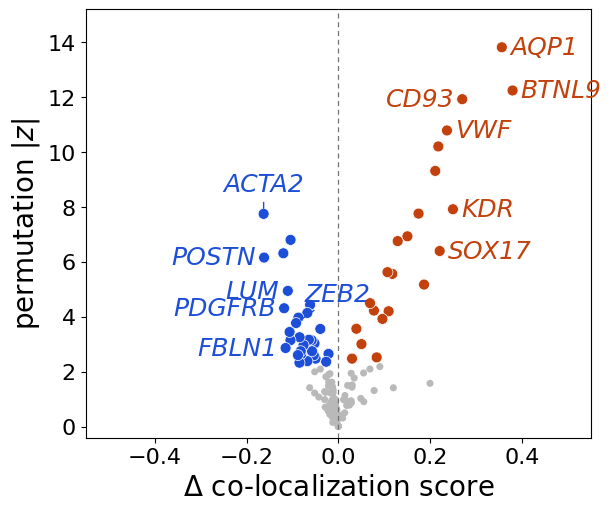

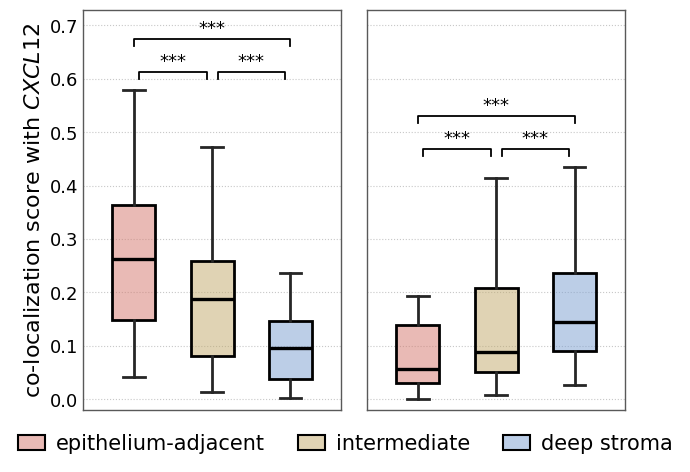

In [8]:
# Fig. 5h
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
from scipy.stats import wilcoxon

GAIN, LOSS, GREY, FDR_CUT = '#C2410C', '#1D4ED8', '#B9B9B9', .05
LABELS = {'AQP1': 'R', 'CD93': 'L', 'BTNL9': 'R', 'VWF': 'R', 'KDR': 'R', 'SOX17': 'R',
          'ACTA2': 'U', 'POSTN': 'L', 'LUM': 'L', 'ZEB2': 'UR', 'PDGFRB': 'L', 'FBLN1': 'L'}
LAB_FS, LAB_DX, LAB_DY = 18, .018, .62
DIRS = {'R': (1, 0), 'L': (-1, 0), 'U': (0, 1), 'D': (0, -1),
        'UR': (1, 1), 'UL': (-1, 1), 'DR': (1, -1), 'DL': (-1, -1)}

R = pd.read_csv(HERE / 'precomputed/cxcl12_partner_shift.csv')
R['y'] = R.z.abs()
sig = (R.fdr < FDR_CUT).values

fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')
ax.scatter(R.delta, R.y, s=np.where(sig, 62, 26), lw=.5, zorder=3,
           c=np.where(~sig, GREY, np.where(R.delta > 0, GAIN, LOSS)),
           edgecolor=np.where(sig, 'white', 'none'))
ax.axvline(0, c='0.45', lw=.9, ls=(0, (4, 3)), zorder=4)
xm = np.abs(R.delta).max() * 1.45
ax.set_xlim(-xm, xm); ax.set_ylim(-.4, R.y.max() * 1.1)

index = {g: i for i, g in enumerate(R.partner)}
for gene, where in LABELS.items():
    r = R.iloc[index[gene]]
    sx, sy = DIRS[where]
    color = GAIN if r.delta > 0 else LOSS
    ax.annotate(gene, (r.delta, r.y), xytext=(r.delta + sx * LAB_DX, r.y + sy * LAB_DY),
                textcoords='data', fontsize=LAB_FS, style='italic', color=color,
                ha='left' if sx > 0 else 'right' if sx < 0 else 'center',
                va='bottom' if sy > 0 else 'top' if sy < 0 else 'center',
                arrowprops=dict(arrowstyle='-', color=color, lw=1, shrinkA=2, shrinkB=4))

ax.set_xlabel('$\\Delta$ co-localization score', fontsize=20)
ax.set_ylabel('permutation $|z|$', fontsize=20)
ax.tick_params(labelsize=16)

plt.show()

CLASSES = ['S_epi', 'S_int', 'S_deep']
CLASS_NAMES = ['epithelium-adjacent', 'intermediate', 'deep stroma']
CLASS_COLORS = ['#D4776C', '#C2A96B', '#7B9FD1']
BRACKETS = [(0, 1, 0), (1, 2, 0), (0, 2, 1)]

significant = R[sig]
fig, axes = plt.subplots(1, 2, figsize=(7, 5.2), gridspec_kw=dict(wspace=0.1))
panels = []
for ax, d in zip(axes, [significant[significant.delta > 0], significant[significant.delta < 0]]):
    scores = [d[c].values for c in CLASSES]
    pvalues = [wilcoxon(scores[i], scores[j]).pvalue for i, j, _ in BRACKETS]

    ax.set_facecolor('white')
    ax.grid(True, axis='y', color='#C8C8C8', lw=.8, ls=':', zorder=0)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color('0.35'); spine.set_linewidth(1.0)
    box = ax.boxplot(scores, positions=[0, 1, 2], widths=.55, patch_artist=True,
                     showfliers=False, zorder=6)
    for patch, color in zip(box['boxes'], CLASS_COLORS):
        patch.set(facecolor=to_rgba(color, .5), edgecolor='k', linewidth=2)
    for key in ('whiskers', 'caps'):
        for element in box[key]:
            element.set(color='0.15', linewidth=2)
    for median in box['medians']:
        median.set(color='k', linewidth=2.4)
    panels.append((ax, pvalues, max(c.get_ydata().max() for c in box['caps'])))

TOP = min(1., max(hi + .020 + .062 + .013 + .055 for _, _, hi in panels))
for ax, pvalues, hi in panels:
    for k, (i, j, level) in enumerate(BRACKETS):
        y = hi + .020 + .062 * level
        x0, x1 = (i + .07, j - .07) if level == 0 else (i, j)
        ax.plot([x0, x0, x1, x1], [y, y + .013, y + .013, y], color='k', lw=1.3)
        stars = ('***' if pvalues[k] < 1e-3 else '**' if pvalues[k] < 1e-2
                 else '*' if pvalues[k] < 5e-2 else 'n.s.')
        ax.text((x0 + x1) / 2, y + .015, stars, ha='center', va='bottom', fontsize=13)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.set_xlim(-.65, 2.65); ax.set_ylim(-.02, TOP)
    ax.tick_params(axis='y', length=0, labelsize=13)
axes[0].set_ylabel(r'co-localization score with $\it{CXCL12}$', fontsize=16)
axes[1].tick_params(labelleft=False)
fig.legend([Patch(facecolor=to_rgba(c, .5), edgecolor='k', lw=1.5) for c in CLASS_COLORS],
           CLASS_NAMES, loc='lower center', bbox_to_anchor=(.5, -.01), ncol=3, frameon=False,
           fontsize=15, handlelength=1.3, handletextpad=.5, columnspacing=1.6)

plt.show()

## Fig. 5i — cell-level and subcellular response of 65 genes to an *in silico* depletion of *LUM* in stromal cells

The x axis is the log2 fold change of predicted counts, the y axis the change in relative
distance to the nuclear center (inward, negative; outward, positive); point color and shape
indicate which of the two readouts is significant at FDR < 0.05.

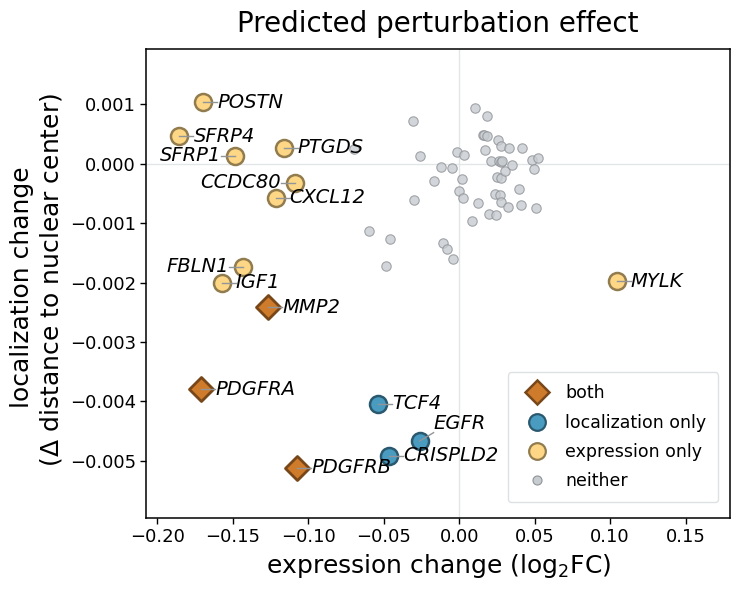

In [9]:
# Fig. 5i
from matplotlib.lines import Line2D

C_EXPR, C_LOC, C_BOTH, C_NONE = '#FDD786', '#499BC0', '#CF7B2C', '#C7CCD1'
STYLE = {'none': dict(c=C_NONE, s=46, lw=0.8, a=0.8, marker='o', zorder=2),
         'expr': dict(c=C_EXPR, s=150, lw=1.8, a=1.0, marker='o', zorder=3),
         'loc': dict(c=C_LOC, s=150, lw=1.8, a=1.0, marker='o', zorder=3),
         'both': dict(c=C_BOTH, s=150, lw=2.0, a=1.0, marker='D', zorder=4)}
FDR = 0.05
CH, LH, RAD = 0.0138, 0.042, 0.024
CAND = [(1, 0, 'left', 'center'), (-1, 0, 'right', 'center'),
        (0, 1, 'center', 'bottom'), (0, -1, 'center', 'top'),
        (1, 1, 'left', 'bottom'), (-1, 1, 'right', 'bottom'),
        (1, -1, 'left', 'top'), (-1, -1, 'right', 'top'),
        (1.9, 0.6, 'left', 'center'), (-1.9, 0.6, 'right', 'center')]

def darken(color, f=0.58):
    """same hue, darker -- the marker edge"""
    r, g, b = (int(color[i:i + 2], 16) for i in (1, 3, 5))
    return '#%02x%02x%02x' % (int(r * f), int(g * f), int(b * f))

def box(cx, cy, w, h, ha, va):
    bx = cx - w / 2 if ha == 'center' else (cx if ha == 'left' else cx - w)
    by = cy if va == 'bottom' else (cy - h if va == 'top' else cy - h / 2)
    return bx, by, w, h

def hit(b, o):
    return not (b[0] + b[2] < o[0] or o[0] + o[2] < b[0]
                or b[1] + b[3] < o[1] or o[1] + o[3] < b[1])

t = pd.read_csv(HERE / 'precomputed/lum_depletion_effects.csv')
sig_c, sig_s = t.q_cell < FDR, t.q_sub < FDR
t['cls'] = np.where(sig_c & sig_s, 'both', np.where(sig_s, 'loc', np.where(sig_c, 'expr', 'none')))

fig, ax = plt.subplots(figsize=(7.5, 6.0))
fig.patch.set_facecolor('white')
ax.axhline(0, color='#e3e6e8', lw=1.0, zorder=1)
ax.axvline(0, color='#e3e6e8', lw=1.0, zorder=1)
for cls, style in STYLE.items():
    m = t.cls == cls
    if m.any():
        kw = dict(style)
        color, lw, alpha = kw.pop('c'), kw.pop('lw'), kw.pop('a')
        ax.scatter(t.cell_effect[m], t.sub_effect[m], facecolor=color, alpha=alpha, linewidths=lw,
                   edgecolor=darken(color, 0.72 if cls == 'none' else 0.58), **kw)

ax.set_xlim(t.cell_effect.min() - 0.022, t.cell_effect.max() + 0.075)
ax.set_ylim(t.sub_effect.min() - 0.00085, t.sub_effect.max() + 0.00090)
(x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
fx = lambda v: (v - x0) / (x1 - x0)
fy = lambda v: (v - y0) / (y1 - y0)
points = [(fx(a), fy(b)) for a, b in zip(t.cell_effect, t.sub_effect)]

placed = []
for _, r in t[t.cls != 'none'].iterrows():
    px, py = fx(r.cell_effect), fy(r.sub_effect)
    w, h = len(r.gene) * CH, LH
    best = None
    for ddx, ddy, ha, va in CAND:
        cx, cy = px + ddx * RAD, py + ddy * RAD * 0.75
        b = box(cx, cy, w, h, ha, va)
        if b[0] < 0.005 or b[0] + b[2] > 0.995 or b[1] < 0.005 or b[1] + b[3] > 0.995:
            continue
        if any(hit(b, o) for o in placed):
            continue
        if any(b[0] - 0.004 < qx < b[0] + b[2] + 0.004 and b[1] - 0.004 < qy < b[1] + b[3] + 0.004
               for qx, qy in points):
            continue
        best = (cx, cy, ha, va, b)
        break
    if best is None:
        cx, cy, ha, va = px + RAD, py + RAD * 0.75, 'left', 'center'
        best = (cx, cy, ha, va, box(cx, cy, w, h, ha, va))
    cx, cy, ha, va, b = best
    placed.append(b)
    ax.annotate(r.gene, (cx, cy), xycoords='axes fraction', fontsize=14, fontstyle='italic',
                color='black', ha=ha, va=va, zorder=5)
    ax.plot([px, cx], [py, cy], transform=ax.transAxes, color='#919598', lw=1, zorder=4)

ax.set_xlabel('expression change (log$_2$FC)', fontsize=18, color='black')
ax.set_ylabel('localization change \n ($\\Delta$ distance to nuclear center)',
              fontsize=18, color='black')
ax.tick_params(labelsize=13, colors='black', direction='out', length=4, width=1.0)
ax.set_axisbelow(True)
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_color('black'); ax.spines[side].set_linewidth(1.1)

ax.legend(handles=[
    Line2D([], [], ls='', marker='D', ms=12, mfc=C_BOTH, mec=darken(C_BOTH), mew=1.8, label='both'),
    Line2D([], [], ls='', marker='o', ms=12, mfc=C_LOC, mec=darken(C_LOC), mew=1.6,
           label='localization only'),
    Line2D([], [], ls='', marker='o', ms=12, mfc=C_EXPR, mec=darken(C_EXPR), mew=1.6,
           label='expression only'),
    Line2D([], [], ls='', marker='o', ms=6.5, mfc=C_NONE, mec=darken(C_NONE, 0.72), mew=0.8,
           label='neither')],
    loc='lower right', bbox_to_anchor=(0.995, 0.015), frameon=True, fontsize=12.5,
    labelcolor='black', handletextpad=0.6, borderpad=0.7, labelspacing=0.65,
    facecolor='white', edgecolor='#dcdfe2', framealpha=0.92)

ax.set_title('Predicted perturbation effect', fontsize=20, pad=12, color='black')
fig.tight_layout()
plt.show()

## Fig. 5j — change in the SVC-predicted subcellular distribution of *CRISPLD2* upon *LUM* depletion, per pixel and summed within six concentric rings

Averaged over cells as the per-pixel change in mass fraction on the 12 x 12 image; each cell's
map is normalized to sum to one before averaging.

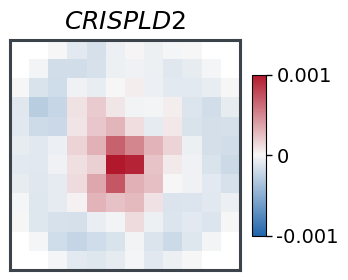

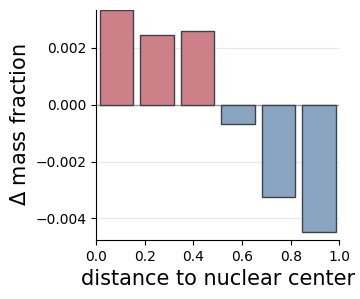

In [10]:
# Fig. 5j
from matplotlib.colors import LinearSegmentedColormap

MAP_GENE, MIN_COUNTS = 'CRISPLD2', 5
CAP = 0.001
PH = 2.30
EDGES = np.linspace(0, 1, 7)

_m = np.load(HERE / f'precomputed/lum_depletion_maps_{MAP_GENE}.npz')
keep = _m['truth_cnt'] >= MIN_COUNTS
map_before, map_p5 = _m['map_before'][keep], _m['map_p5'][keep]

A = (map_before / map_before.sum((-1, -2), keepdims=True)).mean(0)
B = (map_p5 / map_p5.sum((-1, -2), keepdims=True)).mean(0)
delta = B - A
ii, jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
radius = np.minimum(np.sqrt((ii + .5 - 6) ** 2 + (jj + .5 - 6) ** 2) / 6, 1)
foreground = A > 0

DIV = LinearSegmentedColormap.from_list('div', ['#2166ac', '#f7f7f7', '#b2182b']).copy()
DIV.set_bad('white')

rect = lambda fw, fh, x, y, w, h: [x / fw, y / fh, w / fw, h / fh]

FW1, FH1 = 3.6, 2.95
X_MAP, Y1, GAP_CB, W_CB = 0.10, 0.10, 0.12, 0.14

fig = plt.figure(figsize=(FW1, FH1))
fig.patch.set_facecolor('white')
ax = fig.add_axes(rect(FW1, FH1, X_MAP, Y1, PH, PH))
im = ax.imshow(np.where(foreground, delta, np.nan), cmap=DIV, vmin=-CAP, vmax=CAP)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color('#3d434a'); spine.set_linewidth(2.2)
ax.set_title(f'$\\it{{{MAP_GENE}}}$', fontsize=18, pad=8, color='black')

cax = fig.add_axes(rect(FW1, FH1, X_MAP + PH + GAP_CB, Y1 + PH * 0.15, W_CB, PH * 0.70))
cb = fig.colorbar(im, cax=cax, ticks=[-CAP, 0, CAP])
cb.ax.set_yticklabels([f'{-CAP:g}', '0', f'{CAP:g}'])
cb.ax.tick_params(labelsize=14, length=4, width=1.0, colors='black')
plt.show()

centers, ring_delta = [], []
for lo, hi in zip(EDGES[:-1], EDGES[1:]):
    m = foreground & (radius >= lo) & (radius < hi + (1e-9 if hi == 1 else 0))
    centers.append((lo + hi) / 2)
    ring_delta.append(delta[m].sum())
centers, ring_delta = np.array(centers), np.array(ring_delta)

FW2, FH2 = 3.6, 2.95
X_BAR, Y2 = 1.05, 0.62

fig = plt.figure(figsize=(FW2, FH2))
fig.patch.set_facecolor('white')
ax = fig.add_axes(rect(FW2, FH2, X_BAR, Y2, FW2 - X_BAR - 0.12, PH))
ax.axhline(0, color='#9aa0a6', lw=1.0, zorder=1)
ax.bar(centers, ring_delta, width=(EDGES[1] - EDGES[0]) * 0.82, zorder=2,
       color=['#ce8089' if v > 0 else '#89a5c2' for v in ring_delta],
       edgecolor='#3d434a', linewidth=1.0)
ax.set_xlabel('distance to nuclear center', fontsize=15, color='black')
ax.set_ylabel('$\\Delta$ mass fraction', fontsize=15, color='black')
ax.set_xlim(0, 1)
ax.set_ylim(ring_delta.min() * 1.06, ring_delta.max())
ax.tick_params(labelsize=10, colors='black')
ax.grid(axis='y', color='#e6e8ea', lw=0.9)
ax.set_axisbelow(True)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color('black')
plt.show()

## Fig. 5k — per-cell change in the relative distance of *POSTN* transcripts to the nuclear center upon *LUM* depletion, by spatial context, and the corresponding change in the predicted distribution

The right panel is computed as in Fig. 5j and averaged within each spatial context. P values from
two-sided Mann-Whitney U tests.

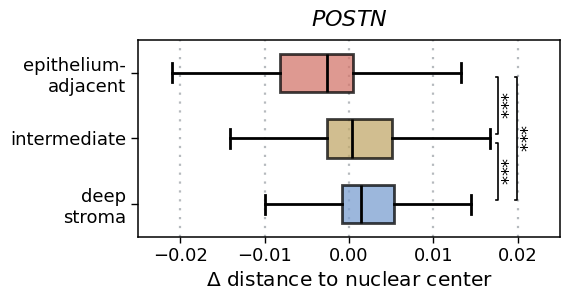

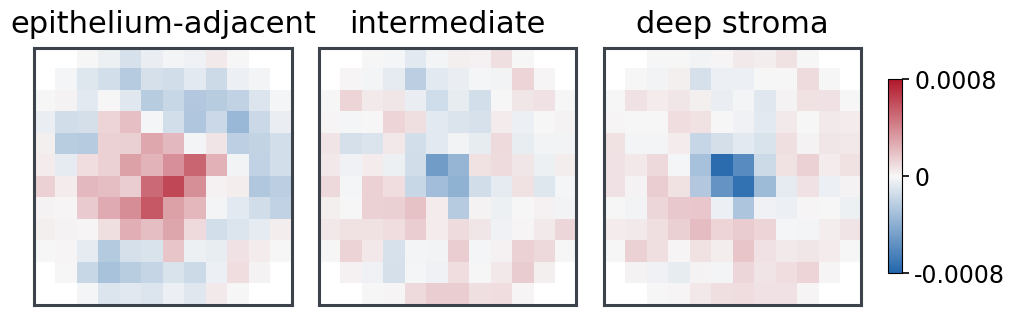

In [11]:
# Fig. 5k
from matplotlib.gridspec import GridSpec
from scipy.stats import mannwhitneyu

CONTEXT_GENE = 'POSTN'
CLASS_NAMES = ['epithelium-adjacent', 'intermediate', 'deep stroma']
COL = {'epithelium-adjacent': '#D4776C', 'intermediate': '#C2A96B', 'deep stroma': '#7B9FD1'}

_c = np.load(HERE / f'precomputed/lum_depletion_{CONTEXT_GENE}.npz', allow_pickle=True)
keep = _c['truth_cnt'] >= MIN_COUNTS
cls = _c['cls'][keep]
rad_delta = (_c['rad_p5'] - _c['rad_before'])[keep]
groups = [rad_delta[cls == c] for c in CLASS_NAMES]
groups = [g[np.isfinite(g)] for g in groups]

fig, ax = plt.subplots(figsize=(5.8, 3.1))
fig.patch.set_facecolor('white')
ax.set_axisbelow(True)
ax.grid(axis='x', color='#b6babe', ls=(0, (1, 3)), lw=1.6)

pos = np.arange(len(groups))
box = ax.boxplot(groups, positions=pos, widths=0.58, vert=False, showfliers=False,
                 patch_artist=True, zorder=3,
                 medianprops=dict(color='black', lw=2.0),
                 whiskerprops=dict(color='black', lw=2.0),
                 capprops=dict(color='black', lw=2.0))
for patch, c in zip(box['boxes'], CLASS_NAMES):
    patch.set(facecolor=COL[c], alpha=0.75, edgecolor='black', linewidth=2.0)

x0 = min(w.get_xdata().min() for w in box['whiskers'])
x1 = max(w.get_xdata().max() for w in box['whiskers'])
span = x1 - x0
LIM = 0.025
ax.set_xlim(-LIM, LIM)

stars = lambda q: '***' if q < 1e-3 else '**' if q < 1e-2 else '*' if q < 0.05 else 'n.s.'
tick = span * 0.008
LEVEL = {(0, 1): 0, (1, 2): 0, (0, 2): 1}
GAP = 0.07
for a, b in [(0, 1), (1, 2), (0, 2)]:
    pv = mannwhitneyu(groups[a], groups[b]).pvalue
    x = x1 + span * (0.02 + 0.06 * LEVEL[(a, b)])
    ya, yb = a + GAP, b - GAP
    ax.plot([x, x + tick, x + tick, x], [ya, ya, yb, yb], lw=1.2, color='black',
            zorder=4, clip_on=False)
    ax.text(x + tick * 1.5, (a + b) / 2, stars(pv), ha='center', va='center', rotation=-90,
            fontsize=13 if pv < 0.05 else 11, color='black', zorder=4, clip_on=False)

wrap = {'epithelium-adjacent': 'epithelium-\nadjacent', 'deep stroma': 'deep\nstroma'}
ax.set_yticks(pos, [wrap.get(c, c) for c in CLASS_NAMES], fontsize=18)
ax.set_ylim(len(groups) - 0.5, -0.5)
ax.set_xticks([-0.02, -0.01, 0, 0.01, 0.02])
ax.set_xlabel('$\\Delta$ distance to nuclear center', fontsize=14.5, color='black')
ax.tick_params(labelsize=13, colors='black', direction='out', length=4, width=1.0)
ax.tick_params(axis='y', length=5)
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_color('black'); ax.spines[side].set_linewidth(1.1)
ax.set_title(f'$\\it{{{CONTEXT_GENE}}}$', fontsize=16, pad=10, color='black')
fig.tight_layout()
plt.show()

CAP_CONTEXT = 0.0008
before, after = _c['map_before'][keep], _c['map_p5'][keep]
panels = []
for c in CLASS_NAMES:
    m = cls == c
    A_ = (before[m] / before[m].sum((-1, -2), keepdims=True)).mean(0)
    B_ = (after[m] / after[m].sum((-1, -2), keepdims=True)).mean(0)
    panels.append((c, A_, B_ - A_))
foreground = panels[0][1] > 0

fig = plt.figure(figsize=(11.2, 4.2))
grid = GridSpec(1, 4, width_ratios=[1, 1, 1, 0.055], wspace=0.14, figure=fig)
fig.patch.set_facecolor('white')
for k, (c, _, delta_k) in enumerate(panels):
    ax = fig.add_subplot(grid[k])
    im = ax.imshow(np.where(foreground, delta_k, np.nan), cmap=DIV,
                   vmin=-CAP_CONTEXT, vmax=CAP_CONTEXT)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#3d434a'); spine.set_linewidth(2.2)
    ax.set_title(c, fontsize=22, pad=11, color='black')
cax = fig.add_subplot(grid[3])
p_ = cax.get_position()
cax.set_position([p_.x0, p_.y0 + p_.height * 0.20, p_.width, p_.height * 0.60])
cb = fig.colorbar(im, cax=cax, ticks=[-CAP_CONTEXT, 0, CAP_CONTEXT])
cb.ax.set_yticklabels([f'{-CAP_CONTEXT:g}', '0', f'{CAP_CONTEXT:g}'])
cb.ax.tick_params(labelsize=17, length=5, width=1.2, colors='black')
plt.show()